In [35]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/k/abdallahwagih/students-performance/__results__.html
/kaggle/input/k/abdallahwagih/students-performance/__resultx__.html
/kaggle/input/k/abdallahwagih/students-performance/__notebook__.ipynb
/kaggle/input/k/abdallahwagih/students-performance/__output__.json
/kaggle/input/k/abdallahwagih/students-performance/custom.css
/kaggle/input/students-performance/student_performance_dataset (1).csv


In [36]:
import pandas as pd 
df=pd.read_csv('/kaggle/input/students-performance/student_performance_dataset (1).csv') 
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 708 entries, 0 to 707
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  708 non-null    object 
 1   Gender                      708 non-null    object 
 2   Study_Hours_per_Week        708 non-null    int64  
 3   Attendance_Rate             708 non-null    float64
 4   Past_Exam_Scores            708 non-null    int64  
 5   Parental_Education_Level    708 non-null    object 
 6   Internet_Access_at_Home     708 non-null    object 
 7   Extracurricular_Activities  708 non-null    object 
 8   Final_Exam_Score            708 non-null    int64  
 9   Pass_Fail                   708 non-null    object 
dtypes: float64(1), int64(3), object(6)
memory usage: 55.4+ KB


In [37]:
df.describe()

,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Final_Exam_Score
count,708.000000,708.000000,708.000000,708.000000
mean,26.132768,78.107722,77.871469,58.771186
std,8.877727,13.802802,14.402739,6.705877
min,10.000000,50.116970,50.000000,50.000000
25%,19.000000,67.550094,65.000000,52.000000
50%,27.000000,79.363046,79.000000,59.500000
75%,34.000000,89.504232,91.000000,64.000000
max,39.000000,99.967675,100.000000,77.000000


In [38]:
df.head()

,Student_ID,Gender,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Parental_Education_Level,Internet_Access_at_Home,Extracurricular_Activities,Final_Exam_Score,Pass_Fail
0,S147,Male,31,68.267841,86,High School,Yes,Yes,63,Pass
1,S136,Male,16,78.222927,73,PhD,No,No,50,Fail
2,S209,Female,21,87.525096,74,PhD,Yes,No,55,Fail
3,S458,Female,27,92.076483,99,Bachelors,No,No,65,Pass
4,S078,Female,37,98.655517,63,Masters,No,Yes,70,Pass


##block 1-data reading and overview
in this block we load the dataset and explore its basic structure.


###dataset description:
this dataset contains information about[sudents performance ]

[column1]:student id
[column2]:gender
[column3]:study-hours-per-week 

##by using df.dtypes we can know the types of each coloumn ex:object,float,intger

###by using df.head() we can read the first 5 rows 

##by using df.describe() we can know statsticisal info. about our data ex:quartiles,max,min,mean, standrad deviation

In [39]:
df.isna()








,Student_ID,Gender,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Parental_Education_Level,Internet_Access_at_Home,Extracurricular_Activities,Final_Exam_Score,Pass_Fail
0,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
703,False,False,False,False,False,False,False,False,False,False
704,False,False,False,False,False,False,False,False,False,False
705,False,False,False,False,False,False,False,False,False,False
706,False,False,False,False,False,False,False,False,False,False


In [40]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
703    False
704     True
705    False
706     True
707    False
Length: 708, dtype: bool

In [41]:
df.drop_duplicates()

,Student_ID,Gender,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Parental_Education_Level,Internet_Access_at_Home,Extracurricular_Activities,Final_Exam_Score,Pass_Fail
0,S147,Male,31,68.267841,86,High School,Yes,Yes,63,Pass
1,S136,Male,16,78.222927,73,PhD,No,No,50,Fail
2,S209,Female,21,87.525096,74,PhD,Yes,No,55,Fail
3,S458,Female,27,92.076483,99,Bachelors,No,No,65,Pass
4,S078,Female,37,98.655517,63,Masters,No,Yes,70,Pass
...,...,...,...,...,...,...,...,...,...,...
701,S118,Female,21,69.858192,90,Masters,Yes,No,50,Fail
702,S358,Female,22,93.349688,76,Bachelors,No,No,60,Pass
703,S492,Male,14,84.658761,78,PhD,Yes,No,50,Fail
705,S473,Male,25,98.384969,75,Bachelors,Yes,No,57,Fail


##block2-checking data 
we do not have missing values so we will drop duplicates only.

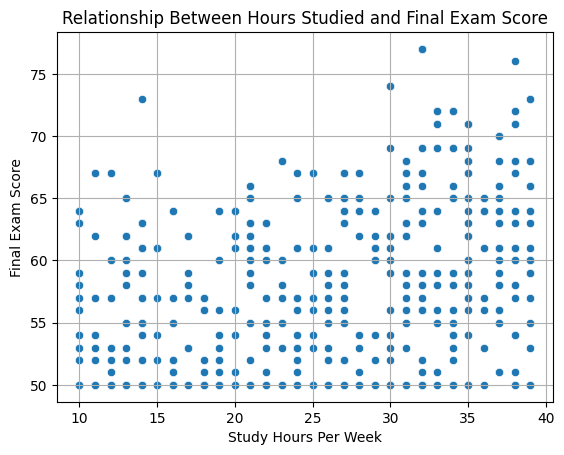

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt


sns.scatterplot(data=df,x='Study_Hours_per_Week',y='Final_Exam_Score')
plt.title('Relationship Between Hours Studied and Final Exam Score')
plt.xlabel('Study Hours Per Week')
plt.ylabel('Final Exam Score')
plt.grid(True)
plt.show()

##block3-visualization
the scatter plot above shows the relationship between the number of hours studied and the final score exam.

##observation
there is a clear positive correlation-students who study more hours tend to have higher final score exam

##conclusion
if i were a school administrator,i would recommend structured study sessions and time management workshops to help students increase their study hours effectively.

### 